In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import zipfile

with zipfile.ZipFile('/content/drive/Shareddrives/depth_estimators/waymo_open/output/images.zip', 'r') as z:
    z.extractall('/content/images/')

In [21]:
import cv2, glob

images = sorted(glob.glob("/content/images/images/*.png"))
assert len(images) > 0, "No images found! Check the zip extraction path."

img = cv2.imread(images[0])
h, w = img.shape[:2]

print(f"Found {len(images)} frames at {w}x{h}")
print(f"Input dir: /content/images/images/")

Found 199 frames at 1920x1280
Input dir: /content/images/images/


In [22]:
!git clone https://github.com/DepthAnything/Depth-Anything-V2 /content/Depth-Anything-V2
!pip install -r /content/Depth-Anything-V2/requirements.txt -q

fatal: destination path '/content/Depth-Anything-V2' already exists and is not an empty directory.


In [23]:
import os
os.makedirs('/content/Depth-Anything-V2/checkpoints', exist_ok=True)

!wget -q --show-progress \
    -O /content/Depth-Anything-V2/checkpoints/depth_anything_v2_vitb.pth \
    https://huggingface.co/depth-anything/Depth-Anything-V2-Base/resolve/main/depth_anything_v2_vitb.pth

print('Done!')

/content/Depth-Anyt 100%[===================>] 371.90M   111MB/s    in 4.2s    
Done!


In [24]:
import os
os.chdir('/content/Depth-Anything-V2')

!python3 run.py \
    --encoder vitb \
    --img-path /content/images/images \
    --outdir /content/depth_output_v2 \
    --pred-only \
    --grayscale

print('Inference complete!')

xFormers not available
xFormers not available
Progress 1/199: /content/images/images/frame_00133.png
Progress 2/199: /content/images/images/frame_00020.png
Progress 3/199: /content/images/images/frame_00185.png
Progress 4/199: /content/images/images/frame_00151.png
Progress 5/199: /content/images/images/frame_00092.png
Progress 6/199: /content/images/images/frame_00137.png
Progress 7/199: /content/images/images/frame_00062.png
Progress 8/199: /content/images/images/frame_00037.png
Progress 9/199: /content/images/images/frame_00057.png
Progress 10/199: /content/images/images/frame_00090.png
Progress 11/199: /content/images/images/frame_00032.png
Progress 12/199: /content/images/images/frame_00186.png
Progress 13/199: /content/images/images/frame_00155.png
Progress 14/199: /content/images/images/frame_00110.png
Progress 15/199: /content/images/images/frame_00097.png
Progress 16/199: /content/images/images/frame_00109.png
Progress 17/199: /content/images/images/frame_00079.png
Progress 18

In [25]:
import numpy as np
import cv2
import glob
from pathlib import Path

DEPTH_PNG_DIR = '/content/depth_output_v2'
DEPTH_OUT     = Path('/content/vda2_output/depth_arrays')
DEPTH_OUT.mkdir(parents=True, exist_ok=True)

depth_files = sorted(glob.glob(f'{DEPTH_PNG_DIR}/frame_*.png'))
print(f'Found {len(depth_files)} depth PNGs')

for i, path in enumerate(depth_files):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
    img_normalized = img / 255.0
    stem = Path(path).stem
    np.save(DEPTH_OUT / f'{stem}_depth.npy', img_normalized)
    if i % 20 == 0:
        print(f'  [{i+1}/{len(depth_files)}] {stem}  shape={img_normalized.shape}  range=[{img_normalized.min():.2f}, {img_normalized.max():.2f}]')

print('Done!')

Found 199 depth PNGs
  [1/199] frame_00000  shape=(1280, 1920)  range=[0.00, 1.00]
  [21/199] frame_00020  shape=(1280, 1920)  range=[0.00, 1.00]
  [41/199] frame_00040  shape=(1280, 1920)  range=[0.00, 1.00]
  [61/199] frame_00060  shape=(1280, 1920)  range=[0.00, 1.00]
  [81/199] frame_00080  shape=(1280, 1920)  range=[0.00, 1.00]
  [101/199] frame_00100  shape=(1280, 1920)  range=[0.00, 1.00]
  [121/199] frame_00120  shape=(1280, 1920)  range=[0.00, 1.00]
  [141/199] frame_00140  shape=(1280, 1920)  range=[0.00, 1.00]
  [161/199] frame_00160  shape=(1280, 1920)  range=[0.00, 1.00]
  [181/199] frame_00180  shape=(1280, 1920)  range=[0.00, 1.00]
Done!


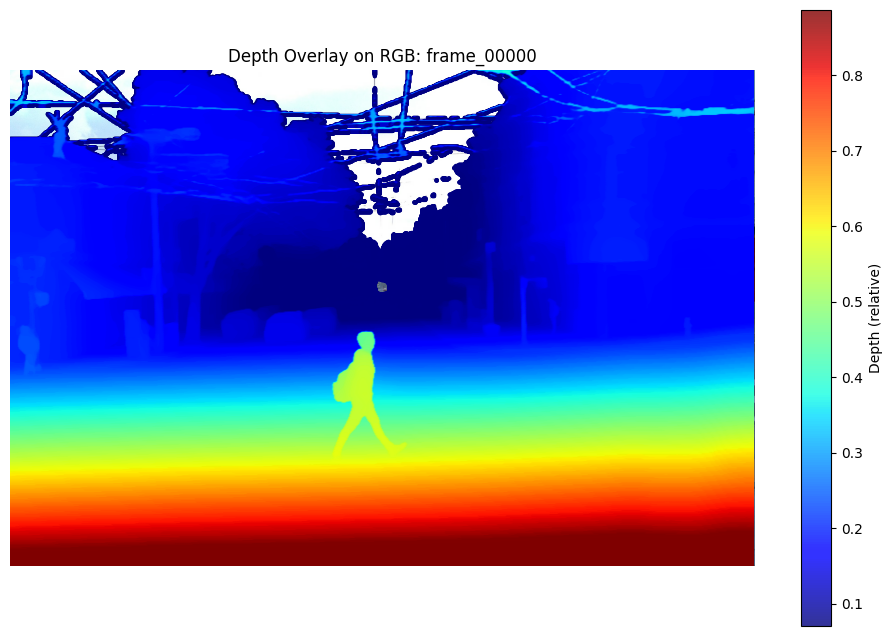

Depth shape: (1280, 1920)
Min depth: 0.0
Max depth: 1.0
Mean depth: 0.353


In [31]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import glob
from pathlib import Path

DEPTH_OUT  = '/content/vda2_output/depth_arrays'
FRAMES_DIR = '/content/images/images'

depth_files = sorted(glob.glob(f'{DEPTH_OUT}/*.npy'))
frame_files = sorted(glob.glob(f'{FRAMES_DIR}/*.png'))

idx = 0
depth = np.load(depth_files[idx])
rgb   = cv2.cvtColor(cv2.imread(frame_files[idx]), cv2.COLOR_BGR2RGB)

valid_mask = depth > 0
ys_img, xs_img = np.where(valid_mask)
vals = depth[valid_mask]

vmin = np.percentile(vals, 5)
vmax = np.percentile(vals, 95)
vals_norm = np.clip(vals, vmin, vmax)

plt.figure(figsize=(12, 8))
plt.imshow(rgb)
plt.scatter(xs_img, ys_img, c=vals_norm, cmap='jet', s=2, alpha=0.8)
plt.colorbar(label='Depth (relative)')
plt.title(f'Depth Overlay on RGB: {Path(frame_files[idx]).stem}')
plt.axis('off')
plt.show()

print("Depth shape:", depth.shape)
print("Min depth:", round(depth.min(), 3))
print("Max depth:", round(depth.max(), 3))
print("Mean depth:", round(depth[valid_mask].mean(), 3))

In [28]:
import numpy as np
import glob
import shutil

DEPTH_OUT   = '/content/vda2_output/depth_arrays'
LOCAL_NPY   = '/content/depthanythingv2_depths.npy'
OUTPUT_NPY  = '/drive/Shareddrives/depth_estimators/VideoDepthAnythingV2/depthanythingv2_depths.npy'

npy_files = sorted(glob.glob(f'{DEPTH_OUT}/*.npy'))
print(f'Loading and stacking {len(npy_files)} frames...')

depth_stack = np.stack([np.load(f) for f in npy_files], axis=0).astype(np.float32)
print(f'Stack shape: {depth_stack.shape}')

# Save locally first
np.save(LOCAL_NPY, depth_stack)
print('Saved locally, copying to Drive...')

# Remount and copy
from google.colab import drive
drive.mount('/drive', force_remount=True)

shutil.copy(LOCAL_NPY, OUTPUT_NPY)
print(f'Done! Saved to {OUTPUT_NPY}')

Loading and stacking 199 frames...
Stack shape: (199, 1280, 1920)
Saved locally, copying to Drive...
Mounted at /drive
Done! Saved to /drive/Shareddrives/depth_estimators/VideoDepthAnythingV2/depthanythingv2_depths.npy
